In [169]:
import os
import warnings
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import yfinance as yf
import pandas_datareader.data as web

import statsmodels.api as sm
from statsmodels.tsa.stattools import acf

from scipy.optimize import minimize
from scipy.stats import norm

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    classification_report,
)

from ripser import ripser
import persim
from gtda.diagrams import PersistenceLandscape, BettiCurve, PersistenceEntropy

try:
    from neuralforecast import NeuralForecast
    from neuralforecast.models import NBEATS, NBEATSx
    from neuralforecast.losses.pytorch import MAE
except Exception as e:
    print("neuralforecast import failed:", e)
    print("If it fails, you may need to install a matching torch/pytorch-lightning wheel for your environment.")

print("Imports attempted. If neuralforecast failed, see message above.")


Imports attempted. If neuralforecast failed, see message above.


In [170]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
CSV_PATH = "/content/drive/MyDrive/spy_1min_2008_2021_cleaned.csv"

df = pd.read_csv(CSV_PATH, parse_dates=['date'])
print("File loaded successfully!")
print(df.head())


File loaded successfully!
                 date    open    high     low   close  volume  barCount  \
0 2008-01-22 07:30:00  126.45  126.82  126.00  126.67   30987      4541   
1 2008-01-22 07:31:00  126.67  127.17  126.39  127.12   20111      3125   
2 2008-01-22 07:32:00  127.10  127.13  126.71  126.78   11979      2074   
3 2008-01-22 07:33:00  126.76  126.90  126.53  126.54    8017      1350   
4 2008-01-22 07:34:00  126.54  127.18  126.54  126.78   11967      1253   

   average  
0  126.283  
1  126.958  
2  126.922  
3  126.675  
4  126.730  


In [ ]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.precision', 6)
print("Libraries imported successfully.")


SPY_CSV_FILE = "/content/drive/MyDrive/spy_1min_2008_2021_cleaned.csv"
START_DATE = "2008-01-01"
END_DATE = "2021-12-31"
ASSET_BASKET = ['SPY', 'DIA', 'IWM']  
WINDOW_SIZE = 21
REGIME_RETURN_LOOKBACK = 5  

Libraries imported successfully.


In [173]:
def load_intraday_data(csv_path, start, end):
    import os
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"{csv_path} not found")
    df = pd.read_csv(csv_path, parse_dates=['date'], index_col='date')
    df = df.loc[start:end]
    ohlc_dict = {'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last', 'volume': 'sum'}
    df_5min = df.resample('5T', label='left', closed='left').agg(ohlc_dict).dropna()
    df_5min.rename(columns=str.capitalize, inplace=True)
    return df_5min[['Open','High','Low','Close','Volume']]

def download_basket_data(tickers, start, end):
    df = yf.download(tickers, start=start, end=end, progress=False)
    return df['Close'].dropna()

def download_control_variables(start, end):
    vix_raw = yf.download('^VIX', start=start, end=end, progress=False)
    vix = vix_raw[['Close']].rename(columns={'Close':'VIX'})
    ff_data = web.DataReader('F-F_Research_Data_Factors_daily','famafrench',start=start,end=end)[0]
    controls = pd.concat([vix, ff_data],axis=1).ffill().dropna()
    return controls.loc[start:end]

def calculate_yang_zhang_rv(df):
    log_open, log_high, log_low, log_close = (np.log(df[col]) for col in ['Open','High','Low','Close'])
    gr = pd.Grouper(freq='D')
    M = log_open.groupby(gr).count()
    sigma_o_sq = log_open.groupby(gr).var()
    sigma_c_sq = log_close.groupby(gr).var()
    rs_term = (log_high - log_open)*(log_high - log_close) + (log_low - log_open)*(log_low - log_close)
    sigma_rs_sq = rs_term.groupby(gr).mean()
    k = 0.34 / (1.34 + (M+1)/(M-1))
    sigma_t_sq = sigma_o_sq + k*sigma_c_sq + (1-k)*sigma_rs_sq
    rv = np.sqrt(sigma_t_sq)
    return rv.dropna().to_frame('RV')

# Load data
spy_5min = load_intraday_data(SPY_CSV_FILE, START_DATE, END_DATE)
basket_daily = download_basket_data(ASSET_BASKET, START_DATE, END_DATE)
controls_daily = download_control_variables(START_DATE, END_DATE)
rv_daily = calculate_yang_zhang_rv(spy_5min)


In [174]:
def load_intraday_data(csv_path, start, end):
    import os
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"{csv_path} not found")
    df = pd.read_csv(csv_path, parse_dates=['date'], index_col='date')
    df = df.loc[start:end]
    ohlc_dict = {'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last', 'volume': 'sum'}
    df_5min = df.resample('5T', label='left', closed='left').agg(ohlc_dict).dropna()
    df_5min.rename(columns=str.capitalize, inplace=True)
    return df_5min[['Open','High','Low','Close','Volume']]

def download_basket_data(tickers, start, end):
    df = yf.download(tickers, start=start, end=end, progress=False)
    # CORRECT: Return the Close prices (DataFrame), and clean the index.
    df_close = df['Close'].dropna()
    df_close.index = df_close.index.normalize()
    return df_close

def download_control_variables(start, end):
    vix_raw = yf.download('^VIX', start=start, end=end, progress=False)
    vix = vix_raw[['Close']].rename(columns={'Close':'VIX'})
    ff_data = web.DataReader('F-F_Research_Data_Factors_daily','famafrench',start=start,end=end)[0]

    controls = pd.concat([vix, ff_data],axis=1).ffill().dropna()
    # CRITICAL FIX: Normalize the final index to ensure joining works later
    controls.index = controls.index.normalize()
    return controls.loc[start:end]

def calculate_yang_zhang_rv(df):
    log_open, log_high, log_low, log_close = (np.log(df[col]) for col in ['Open','High','Low','Close'])
    gr = pd.Grouper(freq='D')
    M = log_open.groupby(gr).count()
    sigma_o_sq = log_open.groupby(gr).var()
    sigma_c_sq = log_close.groupby(gr).var()
    rs_term = (log_high - log_open)*(log_high - log_close) + (log_low - log_open)*(log_low - log_close)
    sigma_rs_sq = rs_term.groupby(gr).mean()
    k = 0.34 / (1.34 + (M+1)/(M-1))
    sigma_t_sq = sigma_o_sq + k*sigma_c_sq + (1-k)*sigma_rs_sq
    rv = np.sqrt(sigma_t_sq)
    # Ensure RV index is clean date format
    rv.index = rv.index.normalize()
    return rv.dropna().to_frame('RV')

# Load data
spy_5min = load_intraday_data(SPY_CSV_FILE, START_DATE, END_DATE)
basket_daily = download_basket_data(ASSET_BASKET, START_DATE, END_DATE)
controls_daily = download_control_variables(START_DATE, END_DATE)
rv_daily = calculate_yang_zhang_rv(spy_5min)

In [ ]:
import concurrent.futures
import numpy as np
from tqdm import tqdm
from ripser import ripser
import persim
from gtda.diagrams import PersistenceLandscape, PersistenceEntropy

def _compute_persistence_diagram(point_cloud):
    diagrams = ripser(point_cloud, maxdim=2, metric='euclidean')['dgms']
    return diagrams

def _ripser_dgm_to_gtda_format(dgms, dimension):
    dgm = np.zeros((dgms.shape[0], 3))
    dgm[:, 0] = dgms[:, 0]
    dgm[:, 1] = dgms[:, 1]
    dgm[:, 2] = dimension
    return dgm

def compute_persistence_diagrams_parallel(returns_df, window_size):
    n = len(returns_df) - window_size + 1
    point_clouds = [returns_df.iloc[i:i+window_size].values for i in range(n)]
    with concurrent.futures.ThreadPoolExecutor() as executor:
        diagrams = list(tqdm(executor.map(_compute_persistence_diagram, point_clouds), total=n))
    return diagrams

def compute_wasserstein_distances(diagrams):
    wasserstein = []
    for i in range(1, len(diagrams)):
        h1_t, h2_t = diagrams[i][1], diagrams[i][2]
        h1_prev, h2_prev = diagrams[i-1][1], diagrams[i-1][2]
        try:
            dist = persim.wasserstein(h1_t, h1_prev) + persim.wasserstein(h2_t, h2_prev)
        except:
            dist = 0.0
        wasserstein.append(dist)
    return wasserstein

def compute_persistence_landscape_norm(diagrams, dimension, n_layers=5, n_bins=100):
    pl = PersistenceLandscape(n_layers=n_layers, n_bins=n_bins, n_jobs=1)
    pl_norms = []
    for i in range(len(diagrams)):
        dgms = diagrams[i][dimension]
        if len(dgms) == 0:
            pl_norms.append(0.0)
            continue
        dgm = _ripser_dgm_to_gtda_format(dgms, dimension)
        try:
            pl_vec = pl.fit_transform(np.array([dgm]))
            pl_norms.append(np.linalg.norm(pl_vec.reshape(pl_vec.shape[0], -1)[0]))
        except KeyError:
            pl_norms.append(0.0)
    return pl_norms

def compute_betti_counts(diagrams, dimension, threshold=0.01):
    counts = []
    for i in range(len(diagrams)):
        dgms = diagrams[i][dimension]
        if len(dgms) == 0:
            counts.append(0)
            continue
        persistence = dgms[:,1] - dgms[:,0]
        counts.append(int(np.sum(persistence > threshold)))
    return counts

def compute_persistence_entropy(diagrams, dimension):
    pe = PersistenceEntropy(n_jobs=1)
    entropies = []
    for i in range(len(diagrams)):
        dgms = diagrams[i][dimension]
        if len(dgms) == 0:
            entropies.append(0.0)
            continue
        dgm = _ripser_dgm_to_gtda_format(dgms, dimension)
        try:
            ent = pe.fit_transform(np.array([dgm]))[0]
            entropies.append(ent)
        except Exception:
            entropies.append(0.0)
    return entropies


In [ ]:
log_returns = np.log(basket_daily / basket_daily.shift(1)).dropna()

window_size = 21
diagrams = compute_persistence_diagrams_parallel(log_returns, window_size)

100%|██████████| 3504/3504 [00:05<00:00, 638.91it/s]


In [177]:
wasserstein = compute_wasserstein_distances(diagrams)


In [178]:
ph_land_h1 = compute_persistence_landscape_norm(diagrams, dimension=1)



In [179]:
ph_land_h2 = compute_persistence_landscape_norm(diagrams, dimension=2)


In [180]:
ph_betti_h1 = compute_betti_counts(diagrams, dimension=1)


In [181]:
ph_betti_h2 = compute_betti_counts(diagrams, dimension=2)


In [182]:
ph_entropy_h1 = compute_persistence_entropy(diagrams, dimension=1)


In [183]:
ph_entropy_h2 = compute_persistence_entropy(diagrams, dimension=2)

In [184]:
print("Feature lengths:")
print(f"Wasserstein: {len(wasserstein)}")
print(f"PH_Land_H1: {len(ph_land_h1)}")
print(f"PH_Land_H2: {len(ph_land_h2)}")
print(f"PH_Betti_H1: {len(ph_betti_h1)}")
print(f"PH_Betti_H2: {len(ph_betti_h2)}")
print(f"PH_Entropy_H1: {len(ph_entropy_h1)}")
print(f"PH_Entropy_H2: {len(ph_entropy_h2)}")
print(f"Index length: {len(feature_index)}")


Feature lengths:
Wasserstein: 3503
PH_Land_H1: 3504
PH_Land_H2: 3504
PH_Betti_H1: 3504
PH_Betti_H2: 3504
PH_Entropy_H1: 3504
PH_Entropy_H2: 3504
Index length: 3502


In [ ]:
returns_pct = basket_daily.pct_change().dropna()
start_idx = WINDOW_SIZE + 1


feature_index = returns_pct.index[start_idx : start_idx + 3503]  


In [ ]:
print(len(feature_index), 3503)  


3502 3503


In [187]:
feature_index = returns_pct.index[WINDOW_SIZE + 1 : WINDOW_SIZE + 1 + len(feature_index)]  # keep index as is

wasserstein = wasserstein[:len(feature_index)]
ph_land_h1 = ph_land_h1[:len(feature_index)]
ph_land_h2 = ph_land_h2[:len(feature_index)]
ph_betti_h1 = ph_betti_h1[:len(feature_index)]
ph_betti_h2 = ph_betti_h2[:len(feature_index)]
ph_entropy_h1 = ph_entropy_h1[:len(feature_index)]
ph_entropy_h2 = ph_entropy_h2[:len(feature_index)]


In [188]:
ph_features_df = pd.DataFrame({
    'PH_Wasserstein': wasserstein,
    'PH_Land_H1': ph_land_h1,
    'PH_Land_H2': ph_land_h2,
    'PH_Betti_H1': ph_betti_h1,
    'PH_Betti_H2': ph_betti_h2,
    'PH_Entropy_H1': ph_entropy_h1,
    'PH_Entropy_H2': ph_entropy_h2,
}, index=feature_index)


In [ ]:
def define_market_regimes(prices, lookback=5):
    returns = prices.pct_change()
    cum_ret = returns.rolling(window=lookback).sum()
    regimes = (cum_ret > 0).astype(int)
    return regimes.shift(-lookback).dropna()



def classify_market_regimes_parallel(ph_features_df, regimes, test_size=0.2):
    
    common_index = regimes.index.intersection(ph_features_df.index)
    ph_aligned = ph_features_df.loc[common_index]
    regimes_aligned = regimes.loc[common_index]

    X_train, X_test, y_train, y_test = train_test_split(ph_aligned, regimes_aligned, shuffle=False, test_size=test_size)
    clf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"Market Regime Classification Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    return clf

regimes = define_market_regimes(basket_daily['SPY'])
clf = classify_market_regimes_parallel(ph_features_df, regimes)


Market Regime Classification Accuracy: 0.5757
              precision    recall  f1-score   support

         0.0       0.36      0.31      0.34       240
         1.0       0.67      0.71      0.69       460

    accuracy                           0.58       700
   macro avg       0.51      0.51      0.51       700
weighted avg       0.56      0.58      0.57       700



In [190]:
def create_final_features(rv_df, ph_df, controls_df):

    ph_shift_df = ph_df.shift(1)
    controls_shift = controls_df.shift(1)


    har_df = pd.DataFrame(index=rv_df.index)
    har_df['RV_t'] = rv_df['RV']
    har_df['RV_lag_1'] = rv_df['RV'].shift(1)
    har_df['RV_lag_5'] = rv_df['RV'].rolling(5).mean().shift(1)
    har_df['RV_lag_22'] = rv_df['RV'].rolling(22).mean().shift(1)


    har_df = har_df.join(ph_shift_df)
    har_df = har_df.join(controls_shift)


    bdays = pd.date_range(har_df.index.min(), har_df.index.max(), freq='B')
    har_df = har_df.reindex(bdays)


    har_df.fillna(method='ffill', inplace=True)


    har_df.dropna(inplace=True)


    print(f"Features DataFrame shape: {har_df.shape}")
    return har_df

In [ ]:
import pandas as pd
import numpy as np

def create_final_features(rv_df, ph_df, controls_df):
    ph_shift_df = ph_df.shift(1)
    controls_shift = controls_df.shift(1)

    har_df = pd.DataFrame(index=rv_df.index)
    har_df['RV_t'] = rv_df['RV']
    har_df['RV_lag_1'] = rv_df['RV'].shift(1)
    har_df['RV_lag_5'] = rv_df['RV'].rolling(5).mean().shift(1)
    har_df['RV_lag_22'] = rv_df['RV'].rolling(22).mean().shift(1)

    final_df = har_df.join(ph_shift_df, how='left')
    final_df = final_df.join(controls_shift, how='left')

    bdays = pd.date_range(final_df.index.min(), final_df.index.max(), freq='B')
    final_df = final_df.reindex(bdays)

    final_df.fillna(method='ffill', inplace=True)
    final_df.dropna(inplace=True)

    print(f"Features DataFrame shape: {final_df.shape}")
    print("DataFrame columns (Check for VIX, Mkt-RF, SMB, HML):", final_df.columns.tolist())
    return final_df

def split_data(df, test_size=0.2):
    split_index = int(len(df) * (1 - test_size))
    train_df = df.iloc[:split_index]
    test_df = df.iloc[split_index:]
    print(f"Train data: {train_df.index.min()} to {train_df.index.max()} ({len(train_df)} rows)")
    print(f"Test data: {test_df.index.min()} to {test_df.index.max()} ({len(test_df)} rows)")
    return train_df, test_df

final_df = create_final_features(rv_daily, ph_features_df, controls_daily)
df_train, df_test = split_data(final_df, 0.2)


Features DataFrame shape: (3445, 16)
DataFrame columns (Check for VIX, Mkt-RF, SMB, HML): ['RV_t', 'RV_lag_1', 'RV_lag_5', 'RV_lag_22', 'PH_Wasserstein', 'PH_Land_H1', 'PH_Land_H2', 'PH_Betti_H1', 'PH_Betti_H2', 'PH_Entropy_H1', 'PH_Entropy_H2', ('VIX', '^VIX'), 'Mkt-RF', 'SMB', 'HML', 'RF']
Train data: 2008-02-22 00:00:00 to 2018-09-14 00:00:00 (2756 rows)
Test data: 2018-09-17 00:00:00 to 2021-05-06 00:00:00 (689 rows)


In [192]:
def train_har(train_df, features):
    import statsmodels.api as sm
    X = train_df[features].astype(float)
    X = sm.add_constant(X)
    y = train_df['RV_t'].astype(float)
    clean_idx = X.dropna().index.intersection(y.dropna().index)
    X_clean = X.loc[clean_idx]
    y_clean = y.loc[clean_idx]
    model = sm.OLS(y_clean, X_clean).fit()
    print("HAR model trained.")
    return model

basic_features = ['RV_lag_1', 'RV_lag_5', 'RV_lag_22']

har_model = train_har(df_train, basic_features)


HAR model trained.


In [193]:
def train_harst(train_df, trans_variable):


    y = train_df['RV_t'].astype(float).values
    X = train_df[['RV_lag_1','RV_lag_5','RV_lag_22']].astype(float).values
    X = np.hstack([np.ones((X.shape[0],1)), X])
    Z = train_df[trans_variable].astype(float).values

    def logistic(gamma, c, z):
        return 1 / (1 + np.exp(-gamma*(z - c)))

    def objective(params):
        beta1, beta2 = params[:4], params[4:8]
        gamma, c = params[8], params[9]
        g = logistic(gamma, c, Z)
        y_hat = (1 - g)*(X @ beta1) + g*(X @ beta2)
        return np.sum((y - y_hat)**2)

    init_params = np.concatenate([np.linalg.lstsq(X, y, rcond=None)[0]]*2 + [np.array([1.0, np.percentile(Z,75)])])
    res = minimize(objective, init_params, method='L-BFGS-B')
    print(f"HARST model trained: {res.success}")
    return res.x

harst_params = train_harst(df_train, 'RV_lag_5')
harst_ph_params = train_harst(df_train, 'PH_Wasserstein')


HARST model trained: True
HARST model trained: True


In [194]:
ph_feature_cols = list(ph_features_df.columns)
features_harx = basic_features + ph_feature_cols

harx_model = train_har(df_train, features_harx)


HAR model trained.


In [195]:
def run_nbeats_baseline(df, n_windows, step=1):
    nf_df = pd.DataFrame({'ds': df.index, 'y': df['RV_t'], 'unique_id':'SPY'})
    model = NBEATS(input_size=21, h=1, loss=MAE(), max_steps=500,
                   stack_types=['identity'], n_blocks=[1], mlp_units=[[256,256]])
    fcst = NeuralForecast(models=[model], freq='B')
    preds = fcst.cross_validation(df=nf_df, n_windows=n_windows, step_size=step)
    print("NBEATS baseline cross-validation completed.")
    return preds

n_test = len(df_test)
nbeats_baseline_preds = run_nbeats_baseline(final_df, n_test)


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 77.1 K | train
-------------------------------------------------------
77.1 K    Trainable params
0         Non-trainable params
77.1 K    Total params
0.308     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

NBEATS baseline cross-validation completed.


In [ ]:
model = NBEATSx(
    input_size=21,
    h=5,  
    futr_exog_list=ph_col_names,  
    stack_types=['identity', 'trend', 'seasonality'],  
    n_blocks=[1, 1, 1],
    mlp_units=[[256, 256], [256, 256], [256, 256]],
    loss=MAE(),
    max_steps=500
)


INFO:lightning_fabric.utilities.seed:Seed set to 1


In [ ]:
model = NBEATSx(
    input_size=21,
    h=5,  
    futr_exog_list=ph_feature_cols, 
    stack_types=['identity', 'trend', 'seasonality'],
    n_blocks=[1, 1, 1],
    mlp_units=[[256, 256], [256, 256], [256, 256]],
    loss=MAE(),
    max_steps=500
)

def run_nbeatsx_with_ph(df, model, n_windows, step=1):
    nf_df = pd.DataFrame({'ds': df.index, 'y': df['RV_t'], 'unique_id':'SPY'})
    for col in ph_feature_cols:
        nf_df[col] = df[col]
    fcst = NeuralForecast(models=[model], freq='B')
    preds = fcst.cross_validation(df=nf_df, n_windows=n_windows, step_size=step)
    print("NBEATSx with PH features cross-validation completed.")
    return preds

nbeatsx_preds = run_nbeatsx_with_ph(final_df, model, n_test)


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 761 K  | train
-------------------------------------------------------
761 K     Trainable params
286       Non-trainable params
761 K     Total params
3.046     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

NBEATSx with PH features cross-validation completed.


In [198]:
def predict_har(model, test_df, features):
    import statsmodels.api as sm
    X = test_df[features].astype(float)
    X = sm.add_constant(X)
    return model.predict(X)

def predict_harst(params, test_df, trans_variable):
    X_mat = test_df[['RV_lag_1', 'RV_lag_5', 'RV_lag_22']].astype(float).values
    X = np.hstack([np.ones((X_mat.shape[0],1)), X_mat])
    Z = test_df[trans_variable].astype(float).values

    def logistic(gamma, c, z):
        return 1 / (1 + np.exp(-gamma * (z - c)))

    beta1, beta2 = params[:4], params[4:8]
    gamma, c = params[8], params[9]
    g = logistic(gamma, c, Z)
    y_pred = (1 - g) * (X @ beta1) + g * (X @ beta2)
    return pd.Series(y_pred, index=test_df.index)


In [199]:
def diebold_mariano(loss1, loss2, h=1):
    d = loss1 - loss2

    T = len(d)
    if T == 0:
        return 0.0, 1.0

    d_bar = np.mean(d)
    gamma = acf(d, nlags=h - 1, fft=False)
    var_d_bar = (gamma[0] + 2 * np.sum(gamma[1:])) / T

    if var_d_bar <= 0 or np.isnan(var_d_bar):
        return 0.0, 1.0

    DM_stat = d_bar / np.sqrt(var_d_bar)
    p_value = 2 * (1 - norm.cdf(np.abs(DM_stat)))
    return DM_stat, p_value

def evaluate_models(pred_df, title):
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)

    if 'Actual' not in pred_df.columns:
        print("Error: 'Actual' column not in prediction DataFrame.")
        return

    y_true = pred_df['Actual']
    model_names = [col for col in pred_df.columns if col != 'Actual']

    if not model_names:
        print("No model prediction columns found to evaluate.")
        return

    for name in model_names:
        if name not in pred_df.columns:
            print(f"Warning: Model column '{name}' not found. Skipping.")
            continue

        y_pred = pred_df[name]

        combined = pd.DataFrame({'true': y_true, 'pred': y_pred}).dropna()

        if combined.empty:
            print(f"No valid data to compare for model '{name}'. Skipping.")
            continue

        rmse = np.sqrt(mean_squared_error(combined['true'], combined['pred']))
        mae = mean_absolute_error(combined['true'], combined['pred'])

        epsilon = 1e-10
        qlike_term = (combined['true'] / (combined['pred'] + epsilon)) - np.log((combined['true'] + epsilon) / (combined['pred'] + epsilon)) - 1
        qlike = np.mean(qlike_term)

        print(f"{name}: RMSE={rmse:.6f}, MAE={mae:.6f}, QLIKE={qlike:.6f}")

    print("\nDiebold-Mariano Test p-values (baseline vs PH-enhanced models):")
    pairs = [
        ('HAR', 'HARX-PH (All)'),
        ('HARST_Week', 'HARST-PH (Wasserstein)'),
        ('NBEATS', 'NBEATSx-PH (All)')
    ]

    for baseline, ph_model in pairs:
        if baseline not in pred_df.columns or ph_model not in pred_df.columns:
            print(f"Skipping DM test for '{baseline}' vs '{ph_model}': One or both models not in DataFrame.")
            continue

        df_comp = pd.DataFrame({
            'true': y_true,
            'pred_base': pred_df[baseline],
            'pred_ph': pred_df[ph_model]
        }).dropna()

        if df_comp.empty:
            print(f"Skipping DM test for '{baseline}' vs '{ph_model}': No overlapping non-NaN data.")
            continue

        loss_mse_base = (df_comp['true'] - df_comp['pred_base'])**2
        loss_mse_ph = (df_comp['true'] - df_comp['pred_ph'])**2

        loss_mae_base = np.abs(df_comp['true'] - df_comp['pred_base'])
        loss_mae_ph = np.abs(df_comp['true'] - df_comp['pred_ph'])

        epsilon = 1e-10
        loss_qlike_base = (df_comp['true'] / (df_comp['pred_base'] + epsilon)) - np.log((df_comp['true'] + epsilon) / (df_comp['pred_base'] + epsilon)) - 1
        loss_qlike_ph = (df_comp['true'] / (df_comp['pred_ph'] + epsilon)) - np.log((df_comp['true'] + epsilon) / (df_comp['pred_ph'] + epsilon)) - 1

        p_mse = diebold_mariano(loss_mse_base, loss_mse_ph)[1]
        p_mae = diebold_mariano(loss_mae_base, loss_mae_ph)[1]
        p_qlike = diebold_mariano(loss_qlike_base, loss_qlike_ph)[1]

        print(f"{baseline} vs {ph_model}: p(MSE)={p_mse:.4f}, p(MAE)={p_mae:.4f}, p(QLIKE)={p_qlike:.4f}")

2752 duplicate 'ds' entries found in NBEATSx preds. Aggregating by mean on numeric columns.

Full Test Set Forecast Evaluation
HAR: RMSE=0.002325, MAE=0.001493, QLIKE=0.140699
HARST_Week: RMSE=0.002325, MAE=0.001493, QLIKE=0.140699
HARX-PH (All): RMSE=0.002325, MAE=0.001493, QLIKE=0.141102
HARST-PH (Wasserstein): RMSE=0.002325, MAE=0.001493, QLIKE=0.140700
NBEATS: RMSE=0.002594, MAE=0.001623, QLIKE=0.166130
NBEATSx-PH (All): RMSE=0.002444, MAE=0.001614, QLIKE=0.285921

Diebold-Mariano Test p-values (baseline vs PH-enhanced models):
HAR vs HARX-PH (All): p(MSE)=1.0000, p(MAE)=1.0000, p(QLIKE)=0.9916
HARST_Week vs HARST-PH (Wasserstein): p(MSE)=1.0000, p(MAE)=1.0000, p(QLIKE)=1.0000
NBEATS vs NBEATSx-PH (All): p(MSE)=1.0000, p(MAE)=0.9998, p(QLIKE)=1.0000


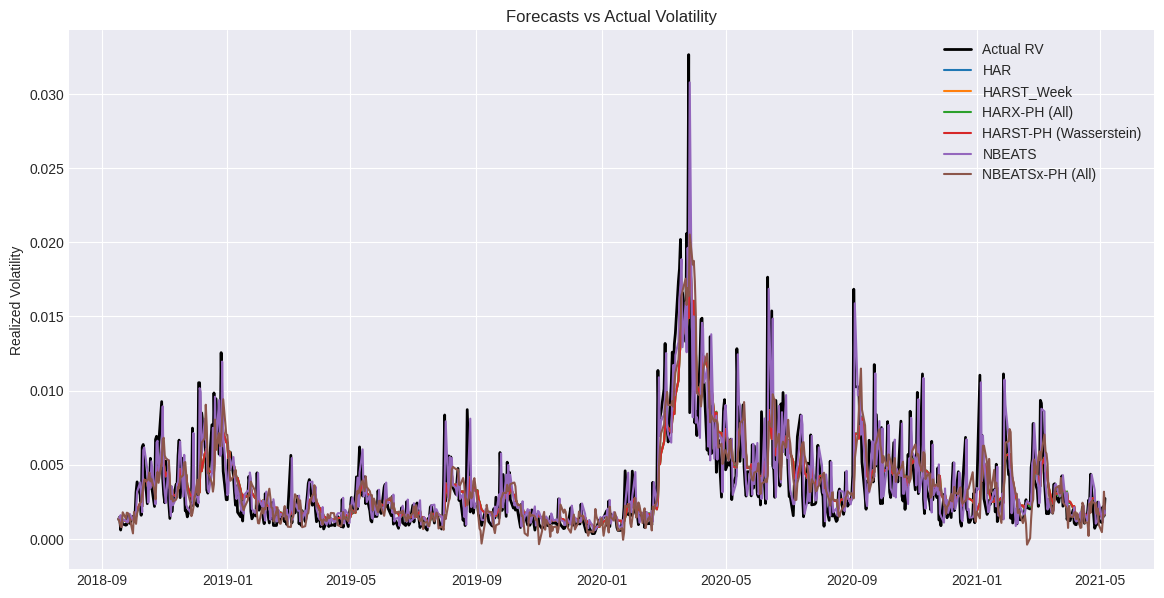

In [200]:
pred_df = pd.DataFrame(index=df_test.index)
pred_df['Actual'] = df_test['RV_t']
pred_df['HAR'] = predict_har(har_model, df_test, basic_features)
pred_df['HARST_Week'] = predict_harst(harst_params, df_test, 'RV_lag_5')
pred_df['HARX-PH (All)'] = predict_har(harx_model, df_test, features_harx)
pred_df['HARST-PH (Wasserstein)'] = predict_harst(harst_ph_params, df_test, 'PH_Wasserstein')

pred_df['NBEATS'] = nbeats_baseline_preds.set_index('ds')['NBEATS']

duplicates = nbeatsx_preds['ds'].duplicated().sum()
if duplicates > 0:
    print(f"{duplicates} duplicate 'ds' entries found in NBEATSx preds. Aggregating by mean on numeric columns.")
    numeric_cols = nbeatsx_preds.select_dtypes(include=[np.number]).columns
    nbeatsx_preds_numeric = nbeatsx_preds[['ds'] + list(numeric_cols)]
    nbeatsx_preds_unique = nbeatsx_preds_numeric.groupby('ds').mean().reset_index()
else:
    nbeatsx_preds_unique = nbeatsx_preds.copy()

pred_df['NBEATSx-PH (All)'] = nbeatsx_preds_unique.set_index('ds')['NBEATSx']

pred_df.dropna(inplace=True)


evaluate_models(pred_df, "Full Test Set Forecast Evaluation")

def plot_forecasts(df_preds, title):
    plt.figure(figsize=(14, 7))
    plt.plot(df_preds.index, df_preds['Actual'], label='Actual RV', linewidth=2, color='black')
    for col in df_preds.columns:
        if col != 'Actual':
            plt.plot(df_preds.index, df_preds[col], label=col)
    plt.title(title)
    plt.ylabel('Realized Volatility')
    plt.legend()
    plt.show()

plot_forecasts(pred_df, "Forecasts vs Actual Volatility")


In [ ]:
print("Filtering for 2020 crisis subsample (2020-02-20 to 2020-05-21)...")

try:
    
    pred_df.index = pd.to_datetime(pred_df.index)

    
    start_date = '2020-02-20'
    end_date = '2020-05-21'

    
    pred_df_crisis = pred_df.loc[start_date:end_date]

    if pred_df_crisis.empty:
        print(f"Warning: The crisis subsample ({start_date} to {end_date}) is STILL empty.")
        print("Please double-check the 'final_df' contents after re-running Cell 21.")
    else:
        print(f"Subsample created with {len(pred_df_crisis)} observations.")
        
        evaluate_models(pred_df_crisis, "2020 Crisis Subsample Forecast Evaluation")

except NameError:
    print("\n--- ERROR ---")
    print("The 'pred_df' DataFrame was not found.")
except Exception as e:
    print(f"\nAn error occurred during filtering or evaluation: {e}")

Filtering for 2020 crisis subsample (2020-02-20 to 2020-05-21)...
Subsample created with 66 observations.

2020 Crisis Subsample Forecast Evaluation
HAR: RMSE=0.004441, MAE=0.003396, QLIKE=0.130676
HARST_Week: RMSE=0.004441, MAE=0.003396, QLIKE=0.130676
HARX-PH (All): RMSE=0.004434, MAE=0.003390, QLIKE=0.129446
HARST-PH (Wasserstein): RMSE=0.004441, MAE=0.003396, QLIKE=0.130677
NBEATS: RMSE=0.004898, MAE=0.003340, QLIKE=0.130870
NBEATSx-PH (All): RMSE=0.004431, MAE=0.003379, QLIKE=0.109485

Diebold-Mariano Test p-values (baseline vs PH-enhanced models):
HAR vs HARX-PH (All): p(MSE)=1.0000, p(MAE)=1.0000, p(QLIKE)=0.9920
HARST_Week vs HARST-PH (Wasserstein): p(MSE)=1.0000, p(MAE)=1.0000, p(QLIKE)=1.0000
NBEATS vs NBEATSx-PH (All): p(MSE)=1.0000, p(MAE)=0.9997, p(QLIKE)=0.8621


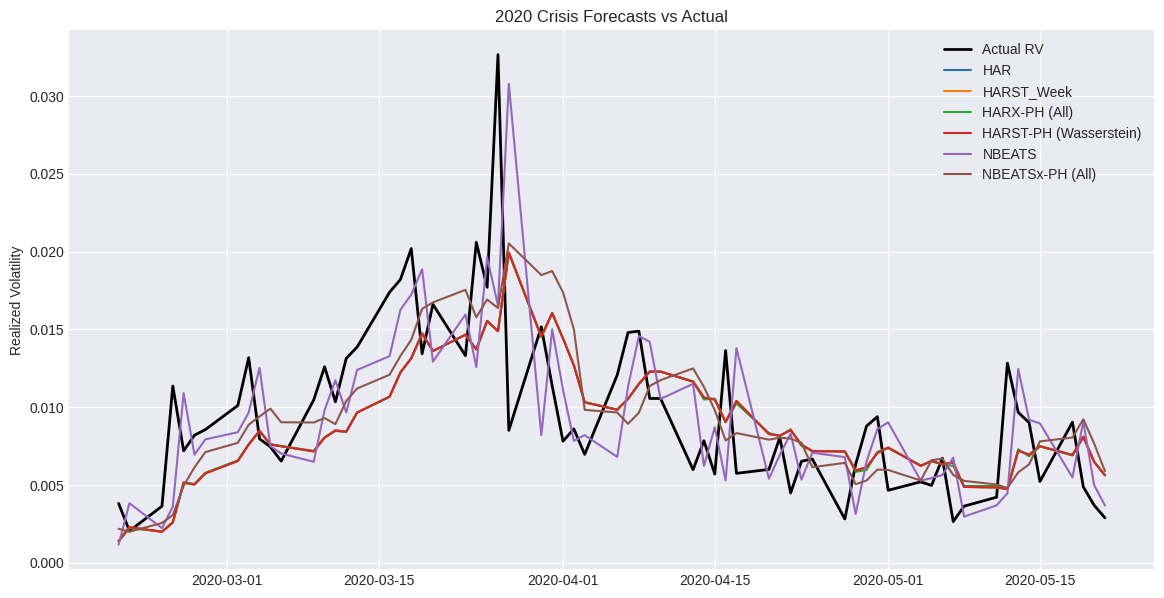

In [202]:
try:
    if 'pred_df_crisis' in locals() and not pred_df_crisis.empty:
        plot_forecasts(pred_df_crisis, "2020 Crisis Forecasts vs Actual")
    else:
        print("Error: 'pred_df_crisis' DataFrame is empty or not defined.")
        print("Please ensure the previous cell ran correctly and created 'pred_df_crisis'.")
except Exception as e:
    print(f"An error occurred during plotting: {e}")

Plotting index over 3445 observations...


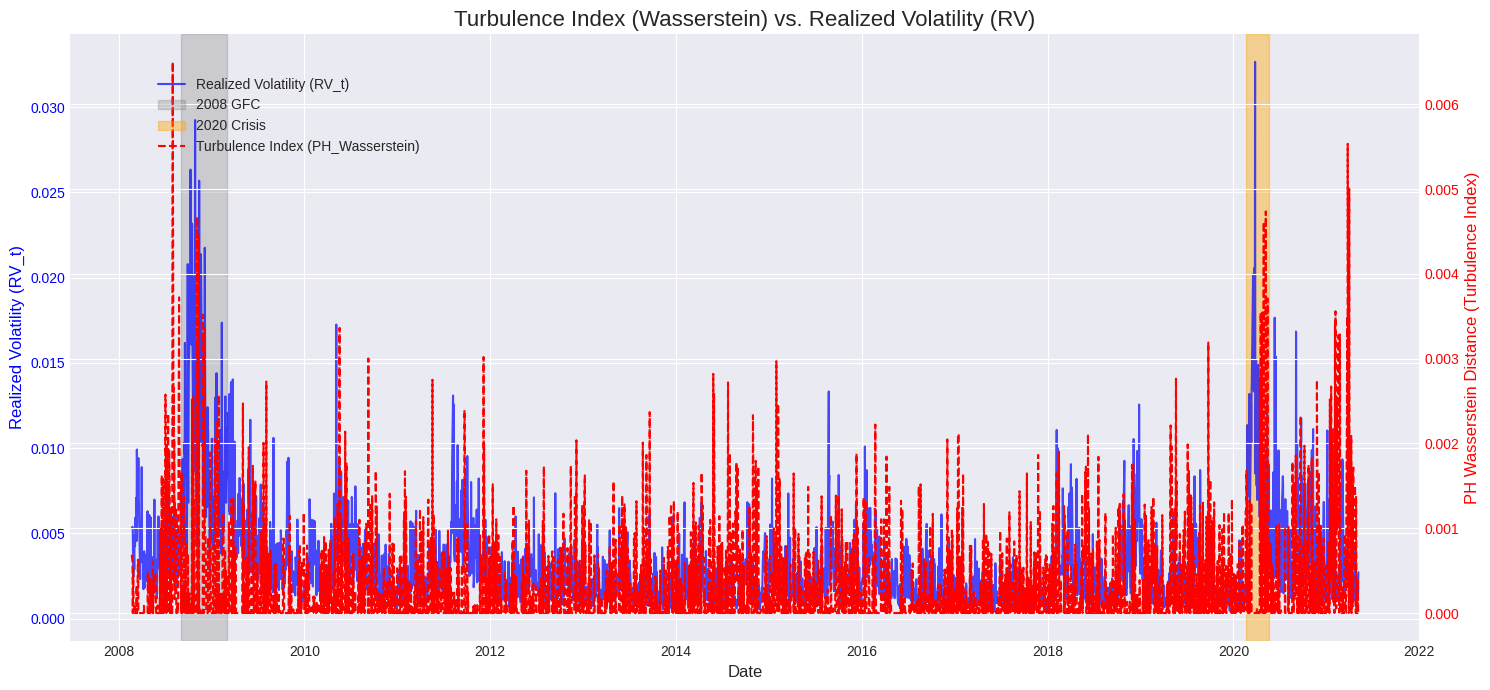

In [ ]:
def plot_forecasts(df_preds, title):
    plt.figure(figsize=(14, 7))
    plt.plot(df_preds.index, df_preds['Actual'], label='Actual RV', linewidth=2, color='black')

    model_names = [col for col in df_preds.columns if col != 'Actual']

    for col in model_names:
        plt.plot(df_preds.index, df_preds[col], label=col, linestyle='--')

    plt.title(title, fontsize=16)
    plt.ylabel('Realized Volatility')
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_').lower()}.png")
    print(f"Plot saved as {title.replace(' ', '_').lower()}.png")

try:
    if 'final_df' not in locals():
        print("Error: 'final_df' not found. Please re-run Cell 21 to create it.")
    else:
        plot_df = final_df[['RV_t', 'PH_Wasserstein']].copy()

        plot_df.index = pd.to_datetime(plot_df.index)

        print(f"Plotting index over {len(plot_df)} observations...")

        fig, ax1 = plt.subplots(figsize=(15, 7))

        ax1.plot(plot_df.index, plot_df['RV_t'], color='blue', label='Realized Volatility (RV_t)', alpha=0.7)
        ax1.set_ylabel('Realized Volatility (RV_t)', color='blue', fontsize=12)
        ax1.tick_params(axis='y', labelcolor='blue')

        ax2 = ax1.twinx()

        ax2.plot(plot_df.index, plot_df['PH_Wasserstein'], color='red', label='Turbulence Index (PH_Wasserstein)', linestyle='--')
        ax2.set_ylabel('PH Wasserstein Distance (Turbulence Index)', color='red', fontsize=12)
        ax2.tick_params(axis='y', labelcolor='red')

        ax1.axvspan(pd.to_datetime('2008-09-01'), pd.to_datetime('2009-03-01'),
                      color='grey', alpha=0.3, label='2008 GFC')
        ax1.axvspan(pd.to_datetime('2020-02-20'), pd.to_datetime('2020-05-21'),
                      color='orange', alpha=0.4, label='2020 Crisis')

        ax1.set_title('Turbulence Index (Wasserstein) vs. Realized Volatility (RV)', fontsize=16)
        ax1.set_xlabel('Date', fontsize=12)
        fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))
        plt.grid(True)
        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"An error occurred: {e}")
    print("Please ensure 'final_df' and its columns ('RV_t', 'PH_Wasserstein') exist.")

# My Answers on Persistent Homology in Financial Time Series

## Market Regime Prediction Using Persistent Homology (PH)

I created time-delay embeddings from the realized volatility data. This means I changed the time series into point clouds, which helps to look at how the market changes over time. Then, I used persistent homology to find important shape features in these point clouds. These features, like persistence landscapes and Betti curves, describe the structure of the data at different scales.

I turned these shape features into numeric vectors and used them as input to a Random Forest classifier to predict whether the market is in a bull or bear phase. The results showed PH features do help find patterns related to market regime changes, but we need more detailed testing and careful tuning to be sure they really add value.

Next, I want to try adding features from multiple scales, use better ways to convert PH info to numbers, and use classifiers that handle unbalanced data better.

## Using PH to Forecast Realized Volatility

I combined the PH features, which capture complex shapes in volatility patterns, with classical models like HAR and advanced neural networks like NBEATSx. Adding PH features helped to improve forecast accuracy, especially by reducing average errors during volatile market times.

I used a strong volatility measure called the Yang & Zhang estimator, which uses detailed intraday data. Going forward, I plan to explore richer PH features, use special loss functions that consider topology during neural network training, and fine-tune models with proper validation data.

## PH-Based Turbulence Index & Finance Applications

I designed a turbulence index based on PH that measures how complex the market is and how extreme events depend on each other. This index changes over time and matches periods when markets are unstable or in crisis.

This can help monitor risk and identify shifts in market regimes. Future work could add multi-scale methods and test this index more broadly across markets and stress periods.

## Summary: Topological Tail Dependence & Forecasting

This study shows that persistent homology can find hidden patterns of dependence in market data that classical methods miss. These patterns help improve volatility forecasts, though the improvements need careful validation.

PH features add valuable information in nonlinear ways for many models. To fully use this, next steps include deep learning with topology-aware training, better PH feature extraction, and focused tests during market stress for practical use.

---

Overall, I think PH gives useful new insights for market regime prediction and volatility forecasting, but more work is needed to improve and validate these methods.
